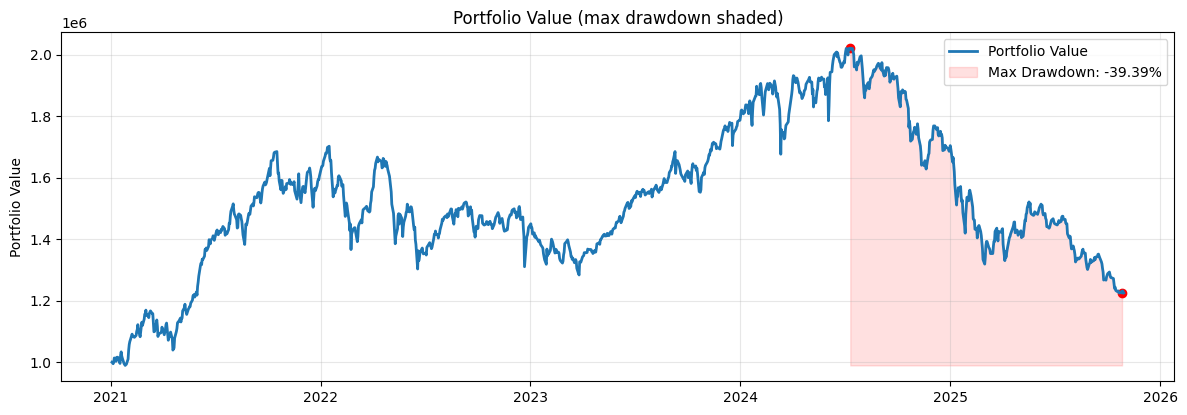

In [10]:
# Paste into a new code cell

%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/gen1u5/Documents/projects/quant-stream/alpha158.csv"
df = pd.read_csv(csv_path, parse_dates=["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")

# compute running max and drawdown
df['cummax'] = df['portfolio_value'].cummax()
df['drawdown'] = df['portfolio_value'] / df['cummax'] - 1

# find max drawdown (most negative drawdown) and its peak-to-trough interval
trough_idx = df['drawdown'].idxmin()
# peak is the index of the maximum portfolio value prior to the trough
peak_idx = df['portfolio_value'][:trough_idx].idxmax() if trough_idx in df.index and not df[:trough_idx].empty else df.index[0]
max_dd = df.loc[trough_idx, 'drawdown'] if trough_idx in df.index else 0.0

plt.figure(figsize=(12,5))
plt.plot(df.index, df["portfolio_value"], lw=2, label='Portfolio Value')

# shade only the max drawdown interval, filling vertically below the portfolio line
mask = (df.index >= peak_idx) & (df.index <= trough_idx)
if mask.any():
    # choose baseline: use 0 when portfolio values are positive, otherwise a bit below the min value
    ymin = df['portfolio_value'].min()
    plt.fill_between(df.index[mask], ymin, df['portfolio_value'][mask], color='red', alpha=0.12, interpolate=True, label=f'Max Drawdown: {max_dd:.2%}')
    # highlight peak and trough points
    plt.scatter([peak_idx, trough_idx], [df.loc[peak_idx,'portfolio_value'], df.loc[trough_idx,'portfolio_value']], color='red')

plt.title("Portfolio Value (max drawdown shaded)")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(rect=(0,0.15,1,1))
plt.show()